<a href="https://colab.research.google.com/github/marianoInsa/ONE-TelecomX-2/blob/main/challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/></a>

# Telecom X - Parte 2: Predicción de Cancelación (Churn)

Luego del análisis exploratorio completo realizado en la Parte 1, ahora damos el siguiente paso: **construir modelos de machine learning capaces de predecir qué clientes tienen mayor probabilidad de cancelar el servicio**.

Antes de entrenar cualquier modelo, el dato crudo (aunque ya procesado en la etapa ETL anterior) necesita ser transformado al formato y escala que los algoritmos de ML requieren. Este notebook cubre esa etapa fundamental: la **preparación de los datos para el modelado**.

---
## ⚙️ Configuración del Entorno

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import mplcyberpunk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Configuración de visualizaciones
plt.style.use("cyberpunk")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'sans-serif'

print('✅ Entorno configurado correctamente.')

✅ Entorno configurado correctamente.


---
## 📥 Carga de Datos

Partimos del dataset limpio y transformado generado en la **Parte 1** del proyecto. Este archivo CSV contiene **7.043 clientes** con **22 variables** que ya pasaron por el pipeline ETL (normalización de JSON anidado, tratamiento de nulos, codificación binaria preliminar y variables derivadas como `cuentas_diarias`).

Al cargar este dataset, evitamos repetir todo el procesamiento previo y nos concentramos exclusivamente en las transformaciones necesarias para el modelado.

In [2]:
API_URL = "https://raw.githubusercontent.com/marianoInsa/ONE-TelecomX/243bebbeb92b071c5d05ed0bf47f1fb9fe25ca2c/data/telecom_data_processed.csv"

df = pd.read_csv(API_URL)

print(f'📊 Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'📋 Columnas: {list(df.columns)}')
df.head()

📊 Dimensiones del dataset: 7043 filas × 22 columnas
📋 Columnas: ['customerID', 'Churn', 'customer_gender', 'customer_seniorcitizen', 'customer_partner', 'customer_dependents', 'customer_tenure', 'phone_phoneservice', 'phone_multiplelines', 'internet_internetservice', 'internet_onlinesecurity', 'internet_onlinebackup', 'internet_deviceprotection', 'internet_techsupport', 'internet_streamingtv', 'internet_streamingmovies', 'account_contract', 'account_paperlessbilling', 'account_paymentmethod', 'account_charges_monthly', 'account_charges_total', 'cuentas_diarias']


,customerID,Churn,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,phone_multiplelines,internet_internetservice,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,account_charges_monthly,account_charges_total,cuentas_diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


### Tipos de datos y valores nulos

Antes de continuar, verificamos el estado del dataset: tipos de datos y presencia de valores faltantes. Esto nos confirma que el trabajo de limpieza de la Parte 1 fue efectivo y podemos avanzar.

In [3]:
print('=== Tipos de datos ===')
print(df.dtypes.to_string())
print(f'\n=== Valores nulos ===')
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else '✅ No hay valores nulos.')

=== Tipos de datos ===
customerID                       str
Churn                          int64
customer_gender                  str
customer_seniorcitizen         int64
customer_partner               int64
customer_dependents            int64
customer_tenure                int64
phone_phoneservice             int64
phone_multiplelines              str
internet_internetservice         str
internet_onlinesecurity          str
internet_onlinebackup            str
internet_deviceprotection        str
internet_techsupport             str
internet_streamingtv             str
internet_streamingmovies         str
account_contract                 str
account_paperlessbilling         str
account_paymentmethod            str
account_charges_monthly      float64
account_charges_total        float64
cuentas_diarias              float64

=== Valores nulos ===
✅ No hay valores nulos.


---
# 🛠️ Preparación de los Datos

## Paso 1: Eliminación de columnas no informativas

No todas las columnas del dataset aportan valor al proceso de predicción. El caso más claro es el **identificador único del cliente** (`customerID`): es simplemente una etiqueta administrativa que no guarda ninguna relación con el comportamiento de cancelación.

Mantener este tipo de variables puede incluso **perjudicar** a ciertos modelos:
- Aumenta la dimensionalidad sin agregar información.
- Algunos algoritmos podrían memorizar patrones espurios asociados a los IDs.

> **Decisión:** Se elimina `customerID` del dataset antes de cualquier procesamiento posterior.

In [4]:
# Eliminamos el identificador único: no aporta poder predictivo
df = df.drop(columns=['customerID'])

print(f'✅ Columna "customerID" eliminada.')
print(f'📊 Nuevo shape: {df.shape[0]} filas × {df.shape[1]} columnas')

✅ Columna "customerID" eliminada.
📊 Nuevo shape: 7043 filas × 21 columnas


---
## Paso 2: Encoding de Variables Categóricas

Los algoritmos de machine learning trabajan exclusivamente con **valores numéricos**. Sin embargo, varias columnas del dataset contienen cadenas de texto como `'Fiber optic'`, `'Month-to-month'` o `'Electronic check'`.

### ¿Qué se transformará?

Al explorar los tipos de datos del CSV, identificamos **dos tipos de situaciones** para las columnas no numéricas:

**A) Columnas binarias con valores `'Yes'`/`'No'` en texto → Conversión directa a 1/0**

| Columna | Detalle |
|---|---|
| `account_paperlessbilling` | Almacenada como `'Yes'`/`'No'` en el CSV, aunque debía ser 0/1 |

Para estas columnas, hacemos un mapeo binario explícito (Yes → 1, No → 0) en lugar de OHE, ya que son naturalmente dicotómicas y no requieren columnas adicionales.

**B) Columnas categóricas multi-clase → One-Hot Encoding (OHE)**

| Columna | Categorías | Cols. generadas (drop_first=True) |
|---|---|---|
| `customer_gender` | Male / Female | 1 |
| `phone_multiplelines` | Yes / No / No phone service | 2 |
| `internet_internetservice` | DSL / Fiber optic / No | 2 |
| `internet_onlinesecurity` | Yes / No / No internet service | 2 |
| `internet_onlinebackup` | Yes / No / No internet service | 2 |
| `internet_deviceprotection` | Yes / No / No internet service | 2 |
| `internet_techsupport` | Yes / No / No internet service | 2 |
| `internet_streamingtv` | Yes / No / No internet service | 2 |
| `internet_streamingmovies` | Yes / No / No internet service | 2 |
| `account_contract` | Month-to-month / One year / Two year | 2 |
| `account_paymentmethod` | 4 métodos de pago | 3 |

Las columnas `customer_partner`, `customer_dependents`, `phone_phoneservice` y `Churn` ya estaban correctamente codificadas como 0/1.

### ¿Por qué `drop_first=True`?

Eliminamos una categoría de referencia por variable para **evitar la multicolinealidad perfecta** (la "trampa de variables dummy"), donde una columna es combinación lineal perfecta de las demás. Esto es especialmente importante para modelos como la Regresión Logística.

In [5]:
# ------------------------------------------------------------------
# A) Columnas binarias almacenadas como texto: conversión Yes/No → 1/0
# ------------------------------------------------------------------
binary_text_cols = ['account_paperlessbilling']
for col in binary_text_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

print(f'✅ Columnas binarias de texto convertidas a 0/1: {binary_text_cols}')

# ------------------------------------------------------------------
# B) Columnas categóricas multi-clase: One-Hot Encoding
#    drop_first=True elimina una categoría por variable para evitar
#    multicolinealidad perfecta (trampa de variables dummy)
# ------------------------------------------------------------------
categorical_cols = [
    'customer_gender',
    'phone_multiplelines',
    'internet_internetservice',
    'internet_onlinesecurity',
    'internet_onlinebackup',
    'internet_deviceprotection',
    'internet_techsupport',
    'internet_streamingtv',
    'internet_streamingmovies',
    'account_contract',
    'account_paymentmethod'
]

cols_antes = df.shape[1]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

cols_despues = df_encoded.shape[1]

print(f'📊 Columnas antes del encoding : {cols_antes}')
print(f'📊 Columnas después del encoding: {cols_despues} (+{cols_despues - cols_antes} columnas dummy)')
print(f'\n✅ Todas las columnas son numéricas: {all(df_encoded.dtypes != object)}')

df_encoded.head()

✅ Columnas binarias de texto convertidas a 0/1: ['account_paperlessbilling']
📊 Columnas antes del encoding : 21
📊 Columnas después del encoding: 32 (+11 columnas dummy)

✅ Todas las columnas son numéricas: True


,Churn,customer_seniorcitizen,customer_partner,customer_dependents,customer_tenure,phone_phoneservice,account_paperlessbilling,account_charges_monthly,account_charges_total,cuentas_diarias,...,internet_techsupport_Yes,internet_streamingtv_No internet service,internet_streamingtv_Yes,internet_streamingmovies_No internet service,internet_streamingmovies_Yes,account_contract_One year,account_contract_Two year,account_paymentmethod_Credit card (automatic),account_paymentmethod_Electronic check,account_paymentmethod_Mailed check
0,0,0,1,1,9,1,1,65.6,593.30,2.19,...,1,0,1,0,0,1,0,0,0,1
1,0,0,0,0,9,1,0,59.9,542.40,2.00,...,0,0,0,0,1,0,0,0,0,1
2,1,0,0,0,4,1,1,73.9,280.85,2.46,...,0,0,0,0,0,0,0,0,1,0
3,1,1,1,0,13,1,1,98.0,1237.85,3.27,...,0,0,1,0,1,0,0,0,1,0
4,1,1,1,0,3,1,1,83.9,267.40,2.80,...,1,0,1,0,0,0,0,0,0,1


In [6]:
# Verificación: listamos las nuevas columnas dummy generadas
nuevas_cols = [c for c in df_encoded.columns if c not in df.columns]
print('📋 Nuevas columnas dummy generadas:')
for col in nuevas_cols:
    print(f'   • {col}')

# Confirmamos que no quedan columnas de tipo object
obj_remaining = [c for c in df_encoded.columns if df_encoded[c].dtype == object]
print(f'\n🔍 Columnas object restantes: {obj_remaining if obj_remaining else "Ninguna ✅"}')
print(f'🔍 Tipos de datos únicos: {set(str(t) for t in df_encoded.dtypes.values)}')

📋 Nuevas columnas dummy generadas:
   • customer_gender_Male
   • phone_multiplelines_No phone service
   • phone_multiplelines_Yes
   • internet_internetservice_Fiber optic
   • internet_internetservice_No
   • internet_onlinesecurity_No internet service
   • internet_onlinesecurity_Yes
   • internet_onlinebackup_No internet service
   • internet_onlinebackup_Yes
   • internet_deviceprotection_No internet service
   • internet_deviceprotection_Yes
   • internet_techsupport_No internet service
   • internet_techsupport_Yes
   • internet_streamingtv_No internet service
   • internet_streamingtv_Yes
   • internet_streamingmovies_No internet service
   • internet_streamingmovies_Yes
   • account_contract_One year
   • account_contract_Two year
   • account_paymentmethod_Credit card (automatic)
   • account_paymentmethod_Electronic check
   • account_paymentmethod_Mailed check

🔍 Columnas object restantes: Ninguna ✅
🔍 Tipos de datos únicos: {'int64', 'float64'}


---
## Paso 3: Análisis del Desbalance de Clases

Antes de entrenar cualquier modelo, es fundamental entender **cómo están distribuidas las clases** en la variable objetivo `Churn`. Un desbalance significativo entre clientes que cancelaron y los que permanecieron activos puede llevar a que el modelo:

- **Sesgue sus predicciones** hacia la clase mayoritaria ("todos se quedan").
- **Muestre una alta accuracy engañosa** sin detectar correctamente los casos de churn.
- **Falle en el recall de la clase minoritaria**, que es precisamente la que más nos interesa predecir.

Ya anticipamos de la Parte 1 que la tasa de churn ronda el **27%**, pero ahora lo cuantificamos formalmente sobre el dataset preparado para el modelado.

In [7]:
# Cálculo de la distribución de clases
class_counts = df_encoded['Churn'].value_counts()
class_pct    = df_encoded['Churn'].value_counts(normalize=True) * 100

print('=== Distribución de la variable objetivo (Churn) ===')
print(f'  Clase 0 | No canceló : {class_counts[0]:>5} clientes  ({class_pct[0]:.2f}%)')
print(f'  Clase 1 | Canceló    : {class_counts[1]:>5} clientes  ({class_pct[1]:.2f}%)')
ratio = class_counts[0] / class_counts[1]
print(f'\n  Ratio de desbalance  : {ratio:.2f}:1 (No Churn / Churn)')

=== Distribución de la variable objetivo (Churn) ===
  Clase 0 | No canceló :  5174 clientes  (73.46%)
  Clase 1 | Canceló    :  1869 clientes  (26.54%)

  Ratio de desbalance  : 2.77:1 (No Churn / Churn)


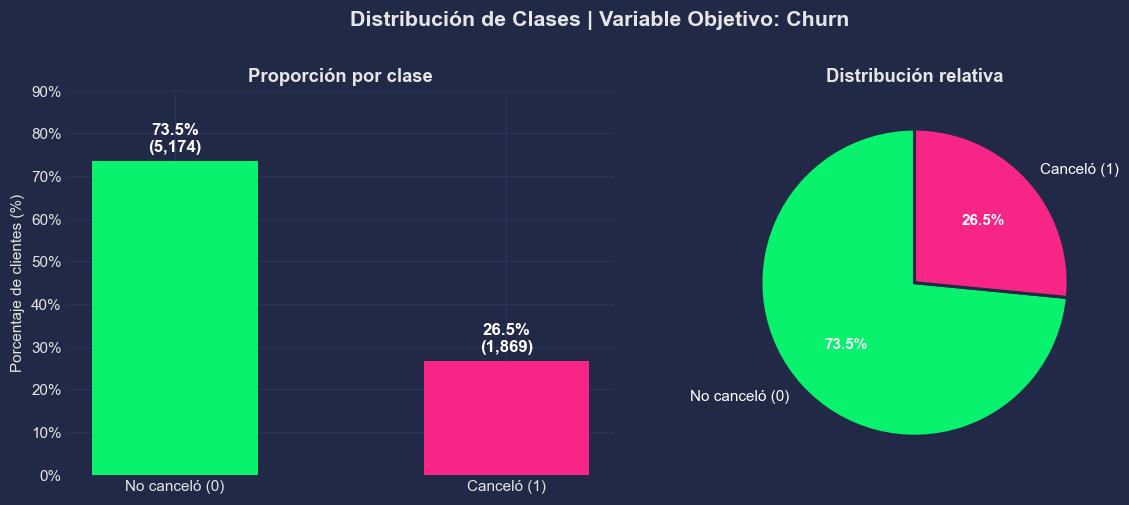

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Distribución de Clases | Variable Objetivo: Churn', fontsize=14, fontweight='bold', y=1.01)

labels = ['No canceló (0)', 'Canceló (1)']
colors = ['#08f26e', '#f72585']

# Barras con porcentaje
bars = axes[0].bar(labels, class_pct.values, color=colors, width=0.5, edgecolor='none')
axes[0].set_title('Proporción por clase', fontweight='bold')
axes[0].set_ylabel('Porcentaje de clientes (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set_ylim(0, 90)
for bar, pct, cnt in zip(bars, class_pct.values, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1.5,
        f'{pct:.1f}%\n({cnt:,})',
        ha='center', va='bottom', fontweight='bold', fontsize=11, color='white'
    )

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    class_counts.values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': '#212946', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')
for t in texts:
    t.set_color('white')
axes[1].set_title('Distribución relativa', fontweight='bold')

mplcyberpunk.add_glow_effects(axes[0])
plt.tight_layout()
plt.show()

### 📌 Evaluación del desbalance

La proporción es aproximadamente **73.5% / 26.5%**, con un ratio de **~2.77:1** (No Churn / Churn). Si bien no es un desbalance extremo como los que se observan en detección de fraude (100:1), **sí es suficiente para afectar el desempeño de los modelos**, en especial para métricas como el **Recall de la clase 1** (detectar correctamente a los clientes que cancelan).

Para un negocio como Telecom X, un **falso negativo** (predecir que un cliente permanece cuando en realidad cancela) es mucho más costoso que un falso positivo. Por eso, **aplicaremos una técnica de balanceo** en el siguiente paso.

---
## Paso 4: División del Dataset y Balanceo de Clases (SMOTE)

### División Train / Test

Antes de aplicar cualquier técnica de balanceo o transformación, dividimos el dataset en un conjunto de **entrenamiento (80%)** y uno de **prueba (20%)**. El parámetro `stratify=y` garantiza que ambos subconjuntos mantengan la misma proporción de clases que el dataset original.

### ¿Por qué aplicar SMOTE *después* del split?

Esta es una decisión crítica: **SMOTE debe aplicarse únicamente sobre el conjunto de entrenamiento**, nunca antes de dividir los datos. Si balanceamos primero, los ejemplos sintéticos generados estarían relacionados con datos del test set, **contaminando la evaluación** (data leakage). El conjunto de test debe replicar fielmente la distribución real del mundo.

### ¿Por qué SMOTE?

Comparamos las alternativas:

| Técnica | Mecanismo | Problema |
|---|---|---|
| **Undersampling aleatorio** | Elimina registros de la clase mayoritaria | Pierde ~3.300 registros con información valiosa |
| **Oversampling aleatorio** | Duplica registros de la clase minoritaria | Introduce exactamente los mismos ejemplos; genera overfitting |
| **SMOTE** ✅ | Genera ejemplos *sintéticos* interpolando vecinos de la clase minoritaria | Sin pérdida de datos; ejemplos nuevos y representativos |

SMOTE ofrece el mejor equilibrio entre preservar información y evitar overfitting por duplicación.

In [9]:
# Separación de features y variable objetivo
X = df_encoded.drop(columns=['Churn'])
y = df_encoded['Churn']

# División 80% entrenamiento / 20% prueba | stratify conserva la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('=== División Train / Test ===')
print(f'  Train : {X_train.shape[0]} registros  ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Test  : {X_test.shape[0]}  registros  ({X_test.shape[0]/len(X)*100:.1f}%)')
print(f'  Features: {X_train.shape[1]} columnas')
print(f'\n  Distribución en Train | Churn: {y_train.mean()*100:.2f}%')
print(f'  Distribución en Test  | Churn: {y_test.mean()*100:.2f}%')

=== División Train / Test ===
  Train : 5634 registros  (80.0%)
  Test  : 1409  registros  (20.0%)
  Features: 31 columnas

  Distribución en Train | Churn: 26.54%
  Distribución en Test  | Churn: 26.54%


In [10]:
# Aplicamos SMOTE SOLO sobre el conjunto de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

bal_counts = pd.Series(y_train_bal).value_counts()
print('=== Distribución después de SMOTE (Train) ===')
print(f'  Clase 0 | No canceló : {bal_counts[0]:>5} registros ({bal_counts[0]/len(y_train_bal)*100:.1f}%)')
print(f'  Clase 1 | Canceló    : {bal_counts[1]:>5} registros ({bal_counts[1]/len(y_train_bal)*100:.1f}%)')
print(f'\n  Ejemplos sintéticos generados: {bal_counts[1] - y_train.sum()} nuevos registros de churn')
print(f'\n✅ Test set permanece intacto: {len(y_test)} registros (sin modificar)')

=== Distribución después de SMOTE (Train) ===
  Clase 0 | No canceló :  4139 registros (50.0%)
  Clase 1 | Canceló    :  4139 registros (50.0%)

  Ejemplos sintéticos generados: 2644 nuevos registros de churn

✅ Test set permanece intacto: 1409 registros (sin modificar)


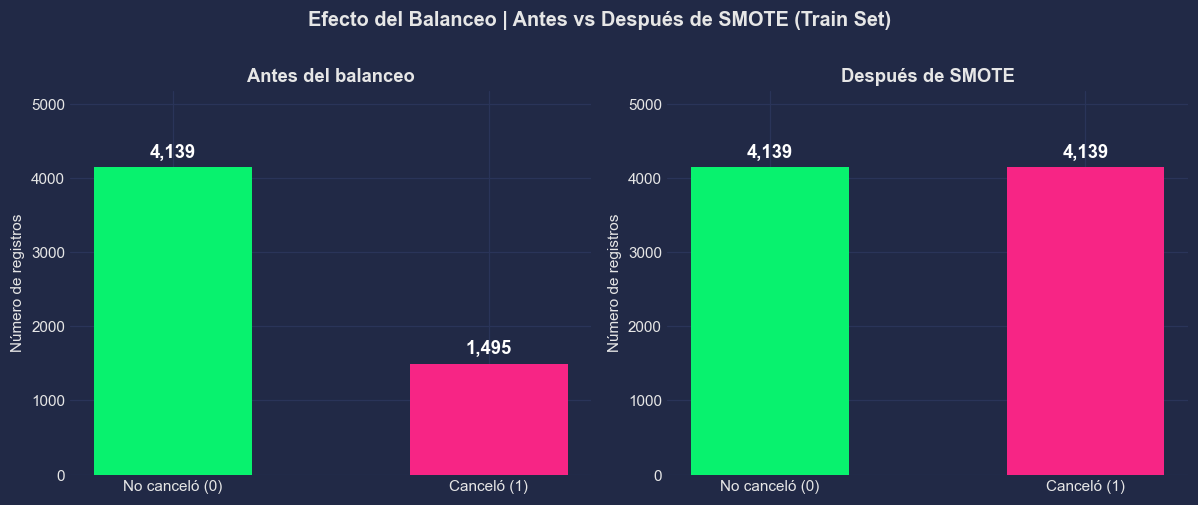

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Efecto del Balanceo | Antes vs Después de SMOTE (Train Set)', fontsize=13, fontweight='bold', y=1.01)

colors = ['#08f26e', '#f72585']
labels = ['No canceló (0)', 'Canceló (1)']

for ax, (counts, title) in zip(axes, [
    (y_train.value_counts(), 'Antes del balanceo'),
    (pd.Series(y_train_bal).value_counts(), 'Después de SMOTE')
]):
    bars = ax.bar(labels, counts.values, color=colors, width=0.5, edgecolor='none')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Número de registros')
    ax.set_ylim(0, max(counts.values) * 1.25)
    for bar, cnt in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts.values) * 0.02,
            f'{cnt:,}',
            ha='center', va='bottom', fontweight='bold', fontsize=12, color='white'
        )
    mplcyberpunk.add_glow_effects(ax)

plt.tight_layout()
plt.show()

---
## Paso 5: Normalización y Estandarización

Las variables numéricas del dataset tienen rangos muy distintos. Por ejemplo:
- `customer_tenure` oscila entre 0 y 72 meses.
- `account_charges_total` llega hasta \$8.500.
- Las columnas dummy son simplemente 0 o 1.

Esta diferencia de escala **no afecta** a los modelos basados en árboles de decisión (Random Forest, XGBoost, Decision Tree), que operan sobre umbrales y divisiones del espacio de features. Sin embargo, **sí impacta significativamente** a los modelos basados en distancias o gradientes:

| Modelo | Sensible a escala | Requiere estandarización |
|---|---|---|
| Regresión Logística | ✅ Sí | ✅ Sí |
| SVM | ✅ Sí | ✅ Sí |
| KNN | ✅ Sí | ✅ Sí |
| Redes Neuronales | ✅ Sí | ✅ Sí |
| Decision Tree | ❌ No | ❌ No |
| Random Forest | ❌ No | ❌ No |
| XGBoost | ❌ No | ❌ No |

### Método elegido: `StandardScaler` (z-score)

Transforma cada feature a **media=0** y **desviación estándar=1**. Se prefiere sobre `MinMaxScaler` porque el dataset tiene outliers en `account_charges_total` que `MinMaxScaler` comprimiría artificialmente.

> **Regla fundamental:** El scaler se **ajusta (fit) exclusivamente sobre el train set** y luego se **aplica (transform)** al test set. Esto evita que información del test contamine el proceso de escalado.

In [12]:
# Estandarización: fit en train balanceado, transform en ambos conjuntos
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_bal)   # Ajusta Y transforma el train
X_test_scaled  = scaler.transform(X_test)            # Solo transforma el test (sin fit)

# Verificación estadística
means = X_train_scaled.mean(axis=0)
stds  = X_train_scaled.std(axis=0)

print('=== Verificación del escalado (Train) ===')
print(f'  Media promedio de todas las features : {means.mean():.6f}  (esperado ≈ 0)')
print(f'  Std  promedio de todas las features  : {stds.mean():.6f}  (esperado ≈ 1)')
print(f'\n  Shape X_train_scaled : {X_train_scaled.shape}')
print(f'  Shape X_test_scaled  : {X_test_scaled.shape}')
print(f'\n✅ Estandarización completada.')

=== Verificación del escalado (Train) ===
  Media promedio de todas las features : 0.000000  (esperado ≈ 0)
  Std  promedio de todas las features  : 1.000000  (esperado ≈ 1)

  Shape X_train_scaled : (8278, 31)
  Shape X_test_scaled  : (1409, 31)

✅ Estandarización completada.


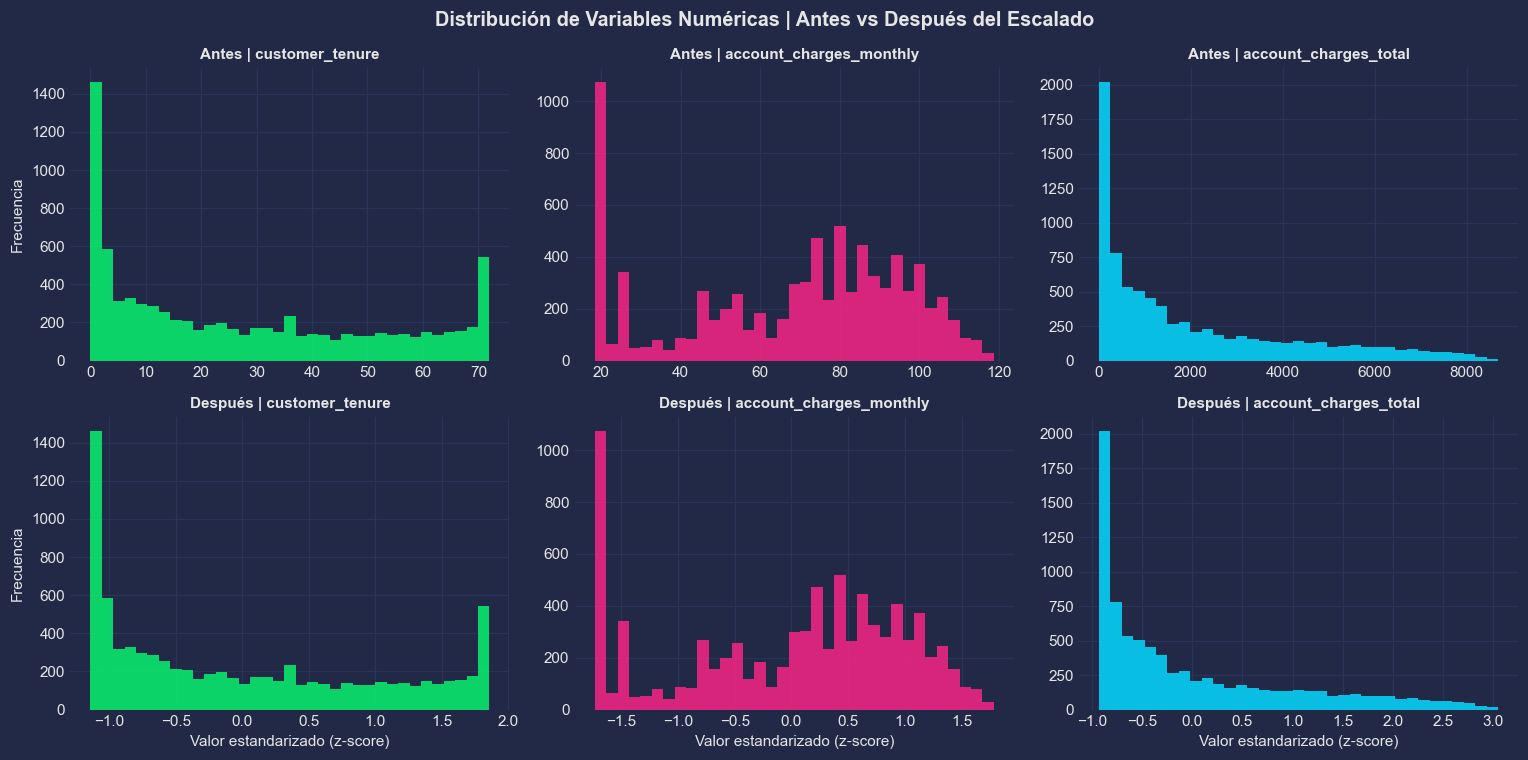

In [13]:
# Visualizamos la distribución de las 3 features numéricas continuas antes y después
num_cols = ['customer_tenure', 'account_charges_monthly', 'account_charges_total']
num_indices = [list(X_train_bal.columns).index(c) for c in num_cols]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Distribución de Variables Numéricas | Antes vs Después del Escalado', fontsize=13, fontweight='bold')

palette = ['#08f26e', '#f72585', '#04d9ff']

for i, (col, idx, color) in enumerate(zip(num_cols, num_indices, palette)):
    # Antes
    axes[0, i].hist(X_train_bal[col], bins=35, color=color, alpha=0.85, edgecolor='none')
    axes[0, i].set_title(f'Antes | {col}', fontsize=10, fontweight='bold')
    axes[0, i].set_ylabel('Frecuencia' if i == 0 else '')

    # Después
    axes[1, i].hist(X_train_scaled[:, idx], bins=35, color=color, alpha=0.85, edgecolor='none')
    axes[1, i].set_title(f'Después | {col}', fontsize=10, fontweight='bold')
    axes[1, i].set_ylabel('Frecuencia' if i == 0 else '')
    axes[1, i].set_xlabel('Valor estandarizado (z-score)')

for row in axes:
    for ax in row:
        mplcyberpunk.add_glow_effects(ax)

plt.tight_layout()
plt.show()

---
## ✅ Resumen de la Preparación de Datos

Completamos todos los pasos de preparación. El dataset ha sido transformado y está listo para el modelado. A continuación, un resumen de las decisiones tomadas:

| Paso | Acción | Justificación |
|---|---|---|
| **1. Drop** | Se eliminó `customerID` | Identificador sin poder predictivo; puede introducir patrones espurios |
| **2. Encoding** | Mapeo binario para `account_paperlessbilling` + OHE con `drop_first=True` en 10 columnas | Compatibilidad con ML; evita multicolinealidad perfecta |
| **3. Desbalance** | Ratio 2.77:1 (No Churn / Churn) detectado | Impacta recall de la clase minoritaria; requiere balanceo |
| **4. SMOTE** | Aplicado post-split, solo en el train set | Genera ejemplos sintéticos realistas sin contaminar la evaluación |
| **5. Escalado** | `StandardScaler` ajustado en `X_train_bal` | Necesario para modelos sensibles a escala; previene data leakage |

### Artefactos generados para el modelado

| Variable | Uso |
|---|---|
| `X_train_bal`, `y_train_bal` | Entrenamiento de modelos basados en **árboles** (sin escalar) |
| `X_train_scaled`, `X_test_scaled` | Entrenamiento y evaluación de modelos **sensibles a escala** |
| `X_test`, `y_test` | Evaluación de todos los modelos (test set real, sin modificar) |
| `scaler` | Para transformar nuevos datos en producción |